In [1]:
"""
================================================================================
DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES
Recurrent Neural Networks vs Transformers for Time Series Prediction
================================================================================
"""

'\n================================================================================\nDEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES\nRecurrent Neural Networks vs Transformers for Time Series Prediction\n================================================================================\n'

In [2]:
"""
================================================================================
STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
================================================================================

BITS ID: 2025AA05327
Name: Anirban Sen
Email: 2025aa05327@wilp.bits-pilani.ac.in
Date: Feb XX, 2026

================================================================================
"""

'\n================================================================================\nSTUDENT INFORMATION (REQUIRED - DO NOT DELETE)\n================================================================================\n\nBITS ID: 2025AA05327\nName: Anirban Sen\nEmail: 2025aa05327@wilp.bits-pilani.ac.in\nDate: Feb XX, 2026\n\n================================================================================\n'

In [3]:
"""
================================================================================
ASSIGNMENT OVERVIEW
================================================================================

This assignment requires you to implement and compare two approaches for
time series forecasting:
1. LSTM or GRU using Keras/PyTorch
2. Transformer encoder using Keras/PyTorch layers

Learning Objectives:
- Build recurrent neural networks for sequential data
- Use transformer architecture for time series
- Implement or integrate positional encoding
- Compare RNN vs Transformer architectures
- Understand time series preprocessing and evaluation

IMPORTANT:
- Positional encoding MUST be added to transformer
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Use temporal train/test split (NO shuffling)

================================================================================
"""

'\n================================================================================\nASSIGNMENT OVERVIEW\n================================================================================\n\nThis assignment requires you to implement and compare two approaches for\ntime series forecasting:\n1. LSTM or GRU using Keras/PyTorch\n2. Transformer encoder using Keras/PyTorch layers\n\nLearning Objectives:\n- Build recurrent neural networks for sequential data\n- Use transformer architecture for time series\n- Implement or integrate positional encoding\n- Compare RNN vs Transformer architectures\n- Understand time series preprocessing and evaluation\n\nIMPORTANT:\n- Positional encoding MUST be added to transformer\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Use temporal train/test split (NO shuffling)\n\n================================================================================\n'

In [4]:
"""
================================================================================
⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️
================================================================================

1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb
   Example: 2025AA05036_rnn_assignment.ipynb
   ❌ Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
   ✓ BITS ID in filename = BITS ID in notebook (above)
   ✓ Name in folder = Name in notebook (above)
   ❌ Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
   ❌ No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
   ❌ Corrupted file = 0 marks

5. IMPLEMENTATION REQUIREMENTS:
   - MUST add positional encoding to transformer (custom or built-in)
   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
   - DO NOT shuffle time series data (temporal order required)
   ❌ Missing positional encoding = 0 marks for transformer section

6. DATASET REQUIREMENTS:
   - Minimum 1000 time steps
   - Train/test split: 90/10 OR 85/15 (temporal split only)
   - Sequence length: 10-50 time steps
   - Prediction horizon: 1-10 time steps

7. USE KERAS OR PYTORCH:
   - Use framework's LSTM/GRU layers
   - Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - Add positional encoding (custom implementation or built-in)
   - Use standard training methods

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

================================================================================
"""

"\n================================================================================\n⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️\n================================================================================\n\n1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb\n   Example: 2025AA05036_rnn_assignment.ipynb\n   ❌ Wrong filename = Automatic 0 marks\n\n2. STUDENT INFORMATION MUST MATCH:\n   ✓ BITS ID in filename = BITS ID in notebook (above)\n   ✓ Name in folder = Name in notebook (above)\n   ❌ Mismatch = 0 marks\n\n3. EXECUTE ALL CELLS BEFORE SUBMISSION:\n   - Run: Kernel → Restart & Run All\n   - Verify all outputs are visible\n   ❌ No outputs = 0 marks\n\n4. FILE INTEGRITY:\n   - Ensure notebook opens without errors\n   - Check for corrupted cells\n   ❌ Corrupted file = 0 marks\n\n5. IMPLEMENTATION REQUIREMENTS:\n   - MUST add positional encoding to transformer (custom or built-in)\n   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n   - DO 

In [84]:
# Import Required Libraries
print("Import Libraries")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

Import Libraries


Deep learning frameworks (choose Keras or PyTorch)

In [6]:
"""
================================================================================
PART 1: DATASET LOADING AND EXPLORATION (Informational)
================================================================================

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the time series data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Stock Prices (daily/hourly closing prices)
- Weather Data (temperature, humidity, pressure)
- Energy Consumption (electricity/power usage)
- Sensor Data (IoT sensor readings)
- Custom time series (with approval)

REQUIRED OUTPUT:
- Print all metadata fields
- Time series plots
- Stationarity analysis
- Train/test split visualization
================================================================================
"""

'\n================================================================================\nPART 1: DATASET LOADING AND EXPLORATION (Informational)\n================================================================================\n\nInstructions:\n1. Choose ONE dataset from the allowed list\n2. Load and explore the time series data\n3. Fill in ALL required metadata fields below\n4. Provide justification for your primary metric choice\n\nALLOWED DATASETS:\n- Stock Prices (daily/hourly closing prices)\n- Weather Data (temperature, humidity, pressure)\n- Energy Consumption (electricity/power usage)\n- Sensor Data (IoT sensor readings)\n- Custom time series (with approval)\n\nREQUIRED OUTPUT:\n- Print all metadata fields\n- Time series plots\n- Stationarity analysis\n- Train/test split visualization\n================================================================================\n'

1.1 Dataset Selection and Loading

In [85]:
# Download and Unzip Dataset
import zipfile
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
zip_path = "AirQualityUCI.zip"
csv_path = "AirQualityUCI.csv"

if not os.path.exists(csv_path):
  print("Downloading dataset...")
  r = requests.get(url)
  with open(zip_path, 'wb') as f:
      f.write(r.content)

  print("Unzipping file...")
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(".")
  print("Unzip complete.")

# Load and basic cleaning
df = pd.read_csv(csv_path, sep=';', decimal=',')
df = df.dropna(subset=['CO(GT)'])
data = df['CO(GT)'].values.reshape(-1, 1)
data

array([[2.6],
       [2. ],
       [2.2],
       ...,
       [2.4],
       [2.1],
       [2.2]])

In [86]:
dataset_name = "UCI Air Quality (CO levels)"
dataset_source = "UCI Machine Learning Repository"
n_samples = len(data)
n_features = 1
sequence_length = 48
prediction_horizon = 1
problem_type = "time_series_forecasting"

# Primary metric selection
primary_metric = "MAE"
metric_justification = """
MAE was chosen as the primary metric because it provides a direct, linear measure of the
average error magnitude in the original units of CO concentration, making it less
sensitive to extreme outliers compared to RMSE.
"""

print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")
print("="*70)


DATASET INFORMATION
Dataset: UCI Air Quality (CO levels)
Source: UCI Machine Learning Repository
Total Samples: 9357
Number of Features: 1
Sequence Length: 48
Prediction Horizon: 1
Primary Metric: MAE
Metric Justification: 
MAE was chosen as the primary metric because it provides a direct, linear measure of the 
average error magnitude in the original units of CO concentration, making it less 
sensitive to extreme outliers compared to RMSE.



1.2 Time Series Exploration

* [x] Plot time series data
* [x] Check for trends, seasonality
* [x] Perform stationarity tests (optional but recommended)

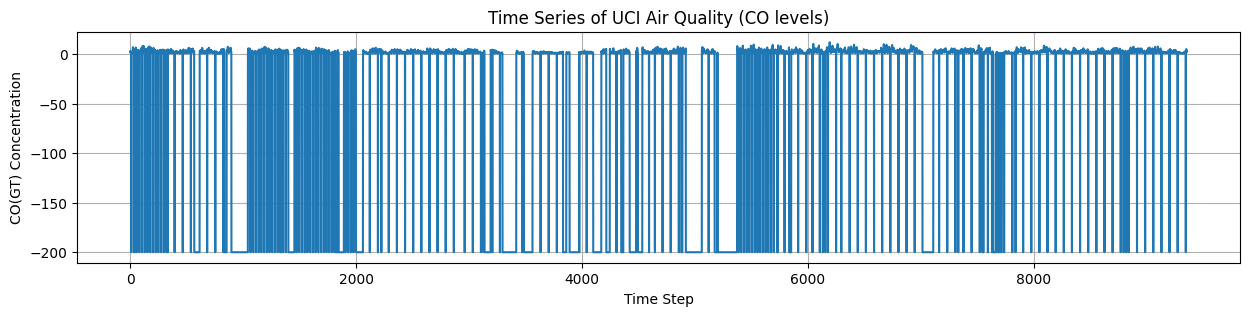

In [12]:
# Plotting the time series
plt.figure(figsize=(15, 3))
plt.plot(data)
plt.title(f'Time Series of {dataset_name}')
plt.xlabel('Time Step')
plt.ylabel('CO(GT) Concentration')
plt.grid(True)
plt.show()

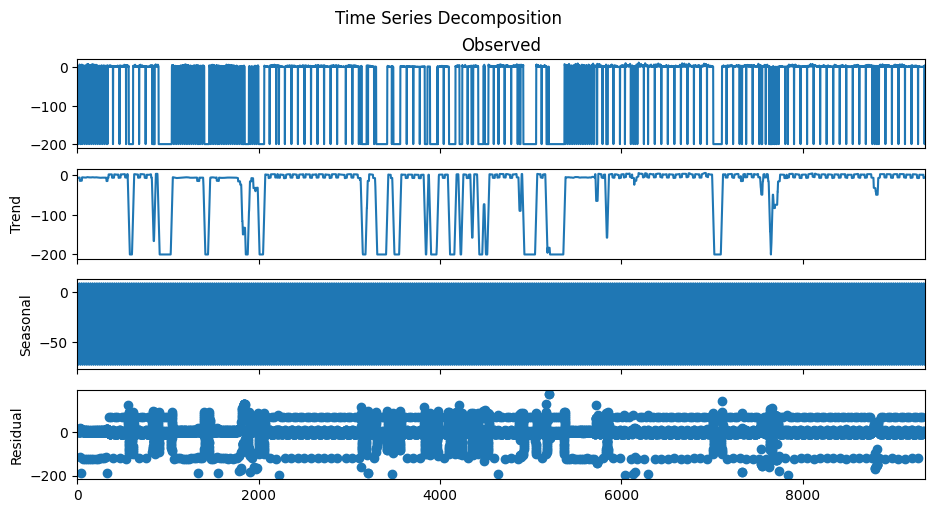

In [13]:
# Perform time series decomposition to visualize trend, seasonality, and residuals
from statsmodels.tsa.seasonal import seasonal_decompose

# Determine frequency. Assuming hourly data and a daily seasonality for CO levels (24 hours)
decomposition = seasonal_decompose(data.flatten(), model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(10, 5)
plt.suptitle('Time Series Decomposition', y=1.02) # Adjust suptitle position
plt.show()

In [14]:
# Stationarity analysis (optional but recommended) - Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    if result[1] <= 0.05:
        print("Reject the null hypothesis (H0), the series is stationary.")
    else:
        print("Fail to reject the null hypothesis (H0), the series is non-stationary.")

print("\n" + "="*70)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("="*70)
check_stationarity(data.flatten())
print("="*70)


STATIONARITY TEST (Augmented Dickey-Fuller)
ADF Statistic: -9.5522
p-value: 0.0000
Critical Values:
	1%: -3.4311
	5%: -2.8618
	10%: -2.5669
Reject the null hypothesis (H0), the series is stationary.


1.3 Data Preprocessing

In [87]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_timeseries(data):
    """
    Preprocess time series data

    Args:
        data: raw time series data

    Returns:
        preprocessed data, scaler
    """
    # 1. Handle Missing Values
    # In the UCI Air Quality dataset, -200 is the marker for NULL/missing values
    if isinstance(data, pd.Series) or isinstance(data, pd.DataFrame):
        data = data.replace(-200, np.nan)
        # Use linear interpolation for time series continuity
        data = data.interpolate(method='linear').fillna(method='bfill')
    else:
        # If it's a numpy array, replace markers with mean or interp
        data[data == -200] = np.nan
        mask = np.isnan(data)
        data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), data[~mask])
    # 2. Normalize Data
    # Using MinMaxScaler as it's standard for LSTM/Transformer inputs
    scaler = MinMaxScaler(feature_range=(0, 1))
    # Ensure data is 2D for the scaler
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)
    preprocessed_data = scaler.fit_transform(data)
    return preprocessed_data, scaler

def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    X = []
    y = []
    # Loop through the data to create overlapping windows
    # We stop when the remaining data is less than (seq_length + pred_horizon)
    for i in range(len(data) - seq_length - pred_horizon + 1):
        # Extract the input sequence: [t, t+1, ..., t+seq_length-1]
        X_window = data[i : (i + seq_length)]
        # Extract the target: [t+seq_length, ..., t+seq_length+pred_horizon-1]
        y_window = data[(i + seq_length) : (i + seq_length + pred_horizon)]
        X.append(X_window)
        y.append(y_window)
    return np.array(X), np.array(y)

# Implementation for the next cell in your template
prep_data, scaler = preprocess_timeseries(data)
X, y = create_sequences(prep_data, seq_length=sequence_length, pred_horizon=1)
print(f"Input shape: {X.shape}")
print(f"Target shape: {y.shape}")

# No shuffling! 90/10 split as per algorithm requirements
split_idx = int(len(prep_data) * 0.9)
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]


Input shape: (9309, 48, 1)
Target shape: (9309, 1, 1)


In [88]:
train_test_ratio = "90/10"
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("⚠️  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 90/10
Training Samples: 8421
Test Samples: 888
⚠️  IMPORTANT: Temporal split used (NO shuffling)


In [20]:
"""
================================================================================
PART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build LSTM OR GRU using Keras/PyTorch layers
- Architecture must include:
  * At least 2 stacked recurrent layers
  * Output layer for prediction
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

GRADING:
- LSTM/GRU architecture with stacked layers: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build LSTM OR GRU using Keras/PyTorch layers\n- Architecture must include:\n  * At least 2 stacked recurrent layers\n  * Output layer for prediction\n- Use model.compile() and model.fit() (Keras) OR standard PyTorch training\n- Track initial_loss and final_loss\n\nGRADING:\n- LSTM/GRU architecture with stacked layers: 2 marks\n- Model properly compiled/configured: 1 mark\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

2.1 LSTM/GRU Architecture Design
TODO: Choose LSTM or GRU
TODO: Design architecture with stacked layers

In [90]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape), # Layer 1
        layers.LSTM(32), # Layer 2 (Stacked)
        layers.Dense(1)
    ])
    return model

rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

2.2 Train RNN Model

In [24]:
print("\n" + "="*70)
print("RNN MODEL TRAINING")
print("="*70)


RNN MODEL TRAINING


In [25]:
# Track training time
rnn_start_time = time.time()

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define Early Stopping: Stop if val_loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True, # Ensures you keep the best model, not the last one
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Reduce learning rate by half (multiply by 0.5)
    patience=5,       # Wait 5 epochs before reducing
    min_lr=1e-6,      # Don't let the learning rate go below this
    verbose=1
)

In [27]:
# Train with the callback
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]  # Add the callback list here
)

Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0132 - mae: 0.0843 - val_loss: 0.0081 - val_mae: 0.0619 - learning_rate: 0.0010
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - loss: 0.0057 - mae: 0.0531 - val_loss: 0.0039 - val_mae: 0.0436 - learning_rate: 0.0010
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0036 - mae: 0.0406 - val_loss: 0.0034 - val_mae: 0.0382 - learning_rate: 0.0010
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.0032 - mae: 0.0382 - val_loss: 0.0033 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 0.0031 - mae: 0.0371 - val_loss: 0.0031 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - loss: 0.0031 - mae: 0.0366 - val_loss: 0.0031 - val_mae: 0.0392 - learning_rate: 0.0010
Epoch 7/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.0029 - mae: 0.0365 - val_loss: 0.0029 - val_mae: 0.0350 - learning_rate:

In [28]:
rnn_training_time = time.time() - rnn_start_time

In [29]:
# Extracting the loss (ensure 'loss' is the key used in your compile step)
rnn_initial_loss = float(rnn_history.history['loss'][0])
rnn_final_loss = float(rnn_history.history['loss'][-1])

In [30]:
print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")
print("="*70)

Training completed in 701.10 seconds
Initial Loss: 0.0098
Final Loss: 0.0022


2.3 Evaluate RNN Model

In [31]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make predictions on test set
rnn_preds = rnn_model.predict(X_test)

# 2. Inverse transform if data was normalized
# Note: Data must be reshaped to match scaler input if it was univariate
rnn_preds_rescaled = scaler.inverse_transform(rnn_preds.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, 1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [32]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-10, y_true))) * 100
    return mape

In [33]:
rnn_mae = mean_absolute_error(y_test_rescaled, rnn_preds_rescaled)
rnn_rmse = np.sqrt(mean_squared_error(y_test_rescaled, rnn_preds_rescaled))
rnn_mape = calculate_mape(y_test_rescaled, rnn_preds_rescaled)
rnn_r2 = r2_score(y_test_rescaled, rnn_preds_rescaled)

In [34]:
print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   0.3811
RMSE:  0.5425
MAPE:  32.1031%
R² Score: 0.8378


2.4 Visualize RNN Results

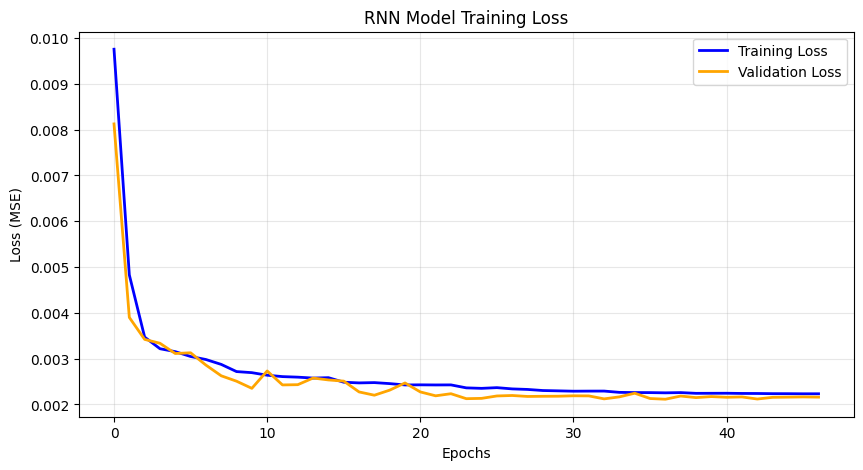

In [35]:
# import matplotlib.pyplot as plt
# import seaborn as sns

def plot_loss(history, model):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
    plt.title(model + ' Model Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(rnn_history, "RNN")

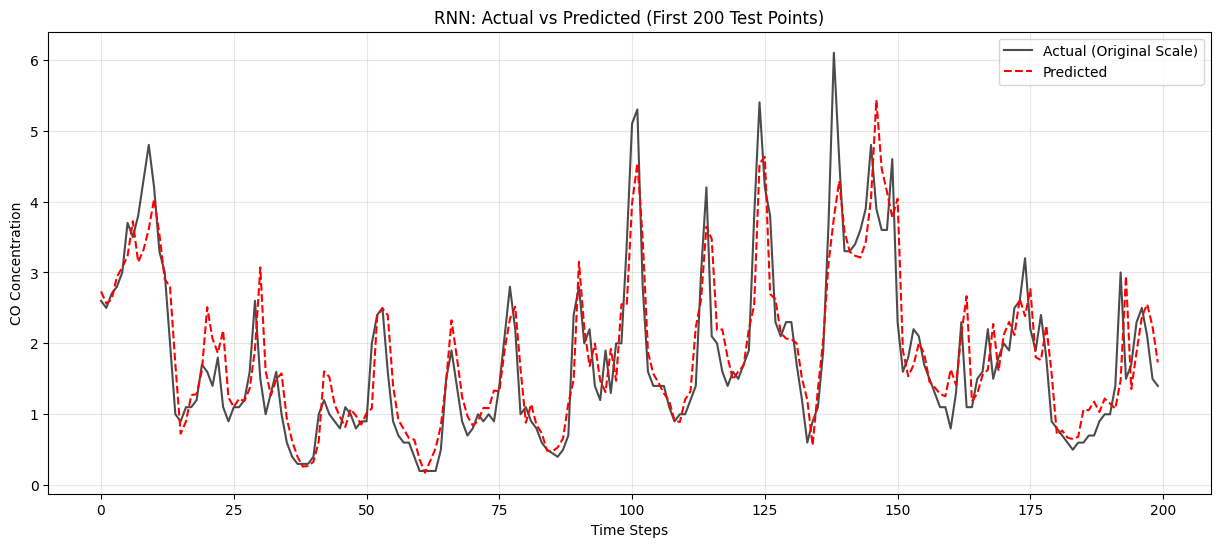

In [36]:
def plot_predictions(y_true, y_pred, model, n_points=200):
    plt.figure(figsize=(15, 6))
    plt.plot(y_true[:n_points], label='Actual (Original Scale)', color='black', alpha=0.7)
    plt.plot(y_pred[:n_points], label='Predicted', color='red', linestyle='--')
    plt.title(f'{model}: Actual vs Predicted (First {n_points} Test Points)')
    plt.xlabel('Time Steps')
    plt.ylabel('CO Concentration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Use the rescaled values calculated in the previous step
plot_predictions(y_test_rescaled, rnn_preds_rescaled, "RNN")

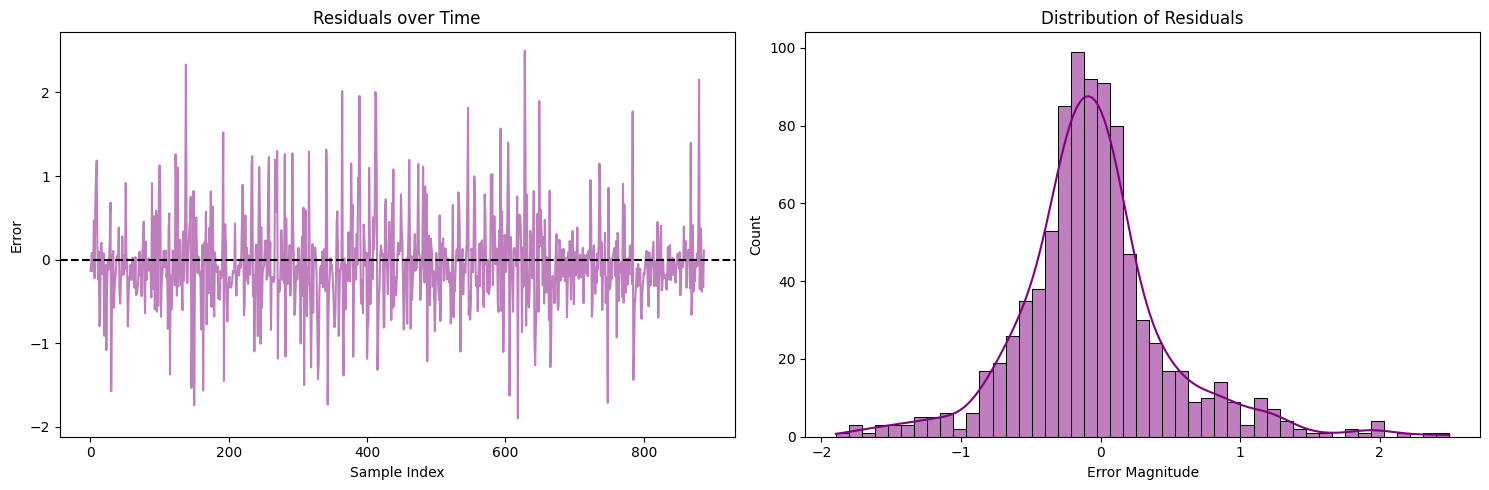

In [37]:
def plot_residuals(y_true, y_pred):
    residuals = y_true.flatten() - y_pred.flatten()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    # Residuals over time
    ax1.plot(residuals, color='purple', alpha=0.5)
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title('Residuals over Time')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Error')
    # Histogram of residuals
    sns.histplot(residuals, kde=True, ax=ax2, color='purple')
    ax2.set_title('Distribution of Residuals')
    ax2.set_xlabel('Error Magnitude')
    plt.tight_layout()
    plt.show()

plot_residuals(y_test_rescaled, rnn_preds_rescaled)

In [38]:
"""
================================================================================
PART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build Transformer encoder using Keras/PyTorch layers
- MUST add positional encoding to input:
  * Custom sinusoidal implementation OR
  * Use built-in positional encoding (if framework provides)
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- Use standard training methods
- Track initial_loss and final_loss

PROHIBITED:
- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Skipping positional encoding entirely

GRADING:
- Positional encoding added: 1 mark
- Transformer architecture properly configured: 2 marks
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build Transformer encoder using Keras/PyTorch layers\n- MUST add positional encoding to input:\n  * Custom sinusoidal implementation OR\n  * Use built-in positional encoding (if framework provides)\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- Use standard training methods\n- Track initial_loss and final_loss\n\nPROHIBITED:\n- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Skipping positional encoding entirely\n\nGRADING:\n- Positional encoding added: 1 mark\n- Transformer architecture properly configured: 2 marks\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

3.1 Positional Encoding Implementation

In [39]:
def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    # 1. Initialize the encoding matrix with zeros
    # Shape: (sequence_length, d_model)
    pos_enc = np.zeros((seq_length, d_model))
    # 2. Create a column vector for positions (0 to seq_length-1)
    # Shape: (seq_length, 1)
    position = np.arange(seq_length)[:, np.newaxis]
    # 3. Calculate the denominator term 10000^(2i/d_model)
    # We compute this in log space for numerical stability:
    # exp(2i * -(log(10000) / d_model))
    # Note: We only need to do this for half the d_model because
    # each 'i' covers one sine and one cosine.
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    # 4. Apply sine to even indices (0, 2, 4...)
    pos_enc[:, 0::2] = np.sin(position * div_term)
    # 5. Apply cosine to odd indices (1, 3, 5...)
    pos_enc[:, 1::2] = np.cos(position * div_term)
    return pos_enc

3.2 Transformer Encoder Architecture

In [40]:
# Option A: Using PyTorch
"""
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff, output_size):
        super().__init__()
        self.input_projection = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)  # Add positional encoding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)  # Add positional encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.fc(x)
"""

'\nimport torch.nn as nn\n\nclass TransformerModel(nn.Module):\n    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff, output_size):\n        super().__init__()\n        self.input_projection = nn.Linear(n_features, d_model)\n        self.pos_encoder = PositionalEncoding(d_model)  # Add positional encoding\n        \n        encoder_layer = nn.TransformerEncoderLayer(\n            d_model=d_model,\n            nhead=n_heads,\n            dim_feedforward=d_ff,\n            batch_first=True\n        )\n        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)\n        self.fc = nn.Linear(d_model, output_size)\n    \n    def forward(self, x):\n        x = self.input_projection(x)\n        x = self.pos_encoder(x)  # Add positional encoding\n        x = self.transformer_encoder(x)\n        x = x.mean(dim=1)  # Global average pooling\n        return self.fc(x)\n'

In [41]:
# Option B: Using Keras

from tensorflow.keras import layers

def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project to d_model
    x = layers.Dense(d_model)(inputs)

    # Add positional encoding
    x = x + positional_encoding(seq_length, d_model)

    # Stack transformer encoder layers
    for _ in range(n_layers):
        # Multi-head attention
        attn_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )(x, x)
        x = layers.LayerNormalization()(x + attn_output)

        # Feed-forward
        ffn_output = layers.Dense(d_ff, activation='relu')(x)
        ffn_output = layers.Dense(d_model)(ffn_output)
        x = layers.LayerNormalization()(x + ffn_output)

    # Output
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(output_size)(x)

    return keras.Model(inputs=inputs, outputs=outputs)

3.3 Build Your Transformer Model

In [42]:
from tensorflow import keras

transformer_model = build_transformer_model(sequence_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)

In [43]:
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

3.4 Train Transformer Model

In [44]:
print("\n" + "="*70)
print("TRANSFORMER MODEL TRAINING")
print("="*70)


TRANSFORMER MODEL TRAINING


In [45]:
# Track training time
transformer_start_time = time.time()

In [46]:
# Define Early Stopping: Stop if val_loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True, # Ensures you keep the best model, not the last one
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Reduce learning rate by half (multiply by 0.5)
    patience=5,       # Wait 5 epochs before reducing
    min_lr=1e-6,      # Don't let the learning rate go below this
    verbose=1
)

transformer_history = transformer_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping, reduce_lr])

Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - loss: 0.3380 - mae: 0.3213 - val_loss: 0.0143 - val_mae: 0.1023 - learning_rate: 0.0010
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.0126 - mae: 0.0857 - val_loss: 0.0122 - val_mae: 0.0915 - learning_rate: 0.0010
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 0.0115 - mae: 0.0804 - val_loss: 0.0056 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.0045 - mae: 0.0490 - val_loss: 0.0033 - val_mae: 0.0417 - learning_rate: 0.0010
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - loss: 0.0034 - mae: 0.0411 - val_loss: 0.0029 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.0038 - mae: 0.0448 - val_loss: 0.0028 - val_mae: 0.0375 - learning_rate: 0.0010
Epoch 7/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - loss: 0.0033 - mae: 0.0404 - val_loss: 0.0027 - val_mae: 0.0347 - learning_rate:

In [47]:
transformer_training_time = time.time() - transformer_start_time

In [48]:
# REQUIRED: Track initial and final loss
transformer_initial_loss = float(transformer_history.history['loss'][0])
transformer_final_loss = float(transformer_history.history['loss'][-1])

In [49]:
print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")
print("="*70)

Training completed in 957.27 seconds
Initial Loss: 0.0940
Final Loss: 0.0023


3.5 Evaluate Transformer Model

In [50]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make predictions on test set
transformer_preds = transformer_model.predict(X_test)

# 2. Inverse transform if data was normalized
# Note: Data must be reshaped to match scaler input if it was univariate
transformer_pred_rescaled = scaler.inverse_transform(transformer_preds.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, 1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [51]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-10, y_true))) * 100
    return mape

In [52]:
# REQUIRED: Calculate all 4 metrics
transformer_mae = mean_absolute_error(y_test_rescaled, transformer_pred_rescaled)
transformer_rmse = np.sqrt(mean_squared_error(y_test_rescaled, transformer_pred_rescaled))
transformer_mape = calculate_mape(y_test_rescaled, transformer_pred_rescaled)
transformer_r2 = r2_score(y_test_rescaled, transformer_pred_rescaled)

In [53]:
print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance:
MAE:   0.3573
RMSE:  0.5303
MAPE:  26.0794%
R² Score: 0.8451


3.6 Visualize Transformer Results

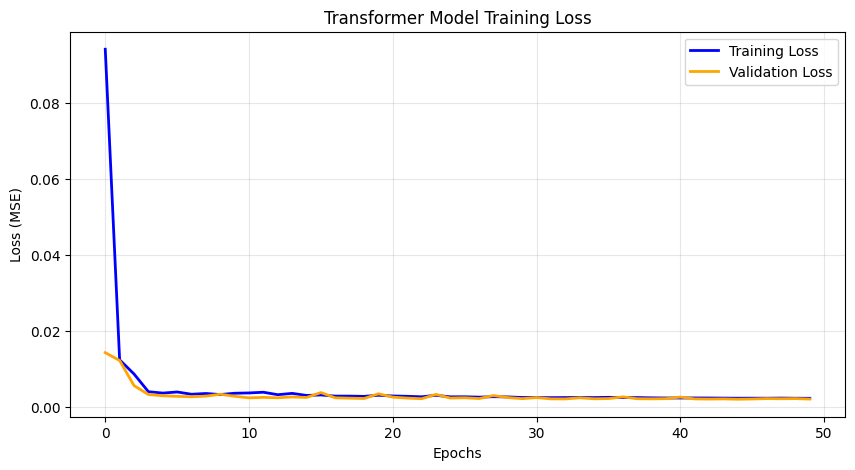

In [54]:
plot_loss(transformer_history, "Transformer")

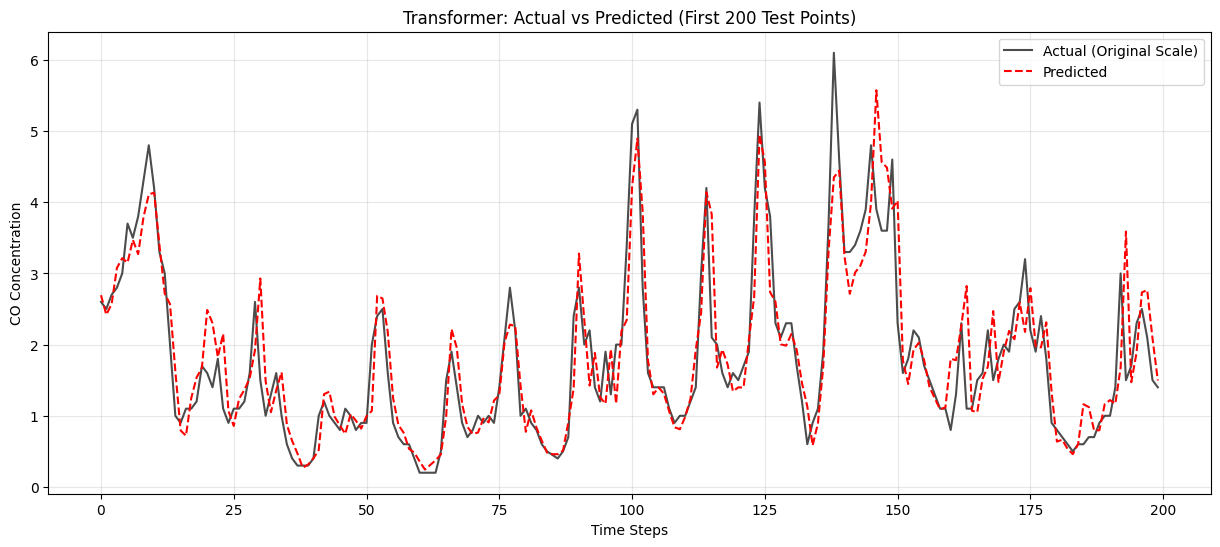

In [55]:
# Use the rescaled values calculated in the previous step
plot_predictions(y_test_rescaled, transformer_pred_rescaled, "Transformer")

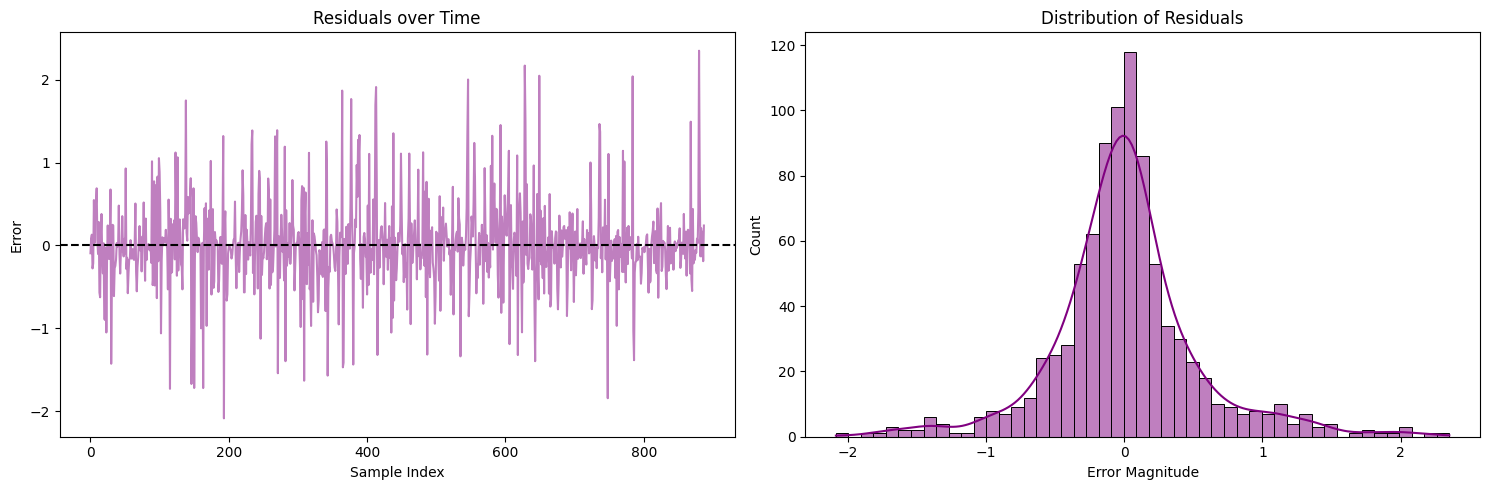

In [56]:
plot_residuals(y_test_rescaled, transformer_pred_rescaled)

In [57]:
"""
================================================================================
PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)
================================================================================

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior
- Ability to capture long-term dependencies
================================================================================
"""

'\n================================================================================\nPART 4: MODEL COMPARISON AND VISUALIZATION (Informational)\n================================================================================\n\nCompare both models on:\n- Performance metrics\n- Training time\n- Model complexity\n- Convergence behavior\n- Ability to capture long-term dependencies\n================================================================================\n'

4.1 Metrics Comparison

In [58]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)


MODEL COMPARISON


In [59]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()
    ]
})

In [60]:
print(comparison_df.to_string(index=False))
print("="*70)

           Metric  RNN (LSTM/GRU)   Transformer
              MAE        0.381114      0.357334
             RMSE        0.542498      0.530295
         MAPE (%)       32.103057     26.079350
         R² Score        0.837847      0.845060
Training Time (s)      701.102521    957.267572
       Parameters    29345.000000 100161.000000


4.2 Visual Comparison

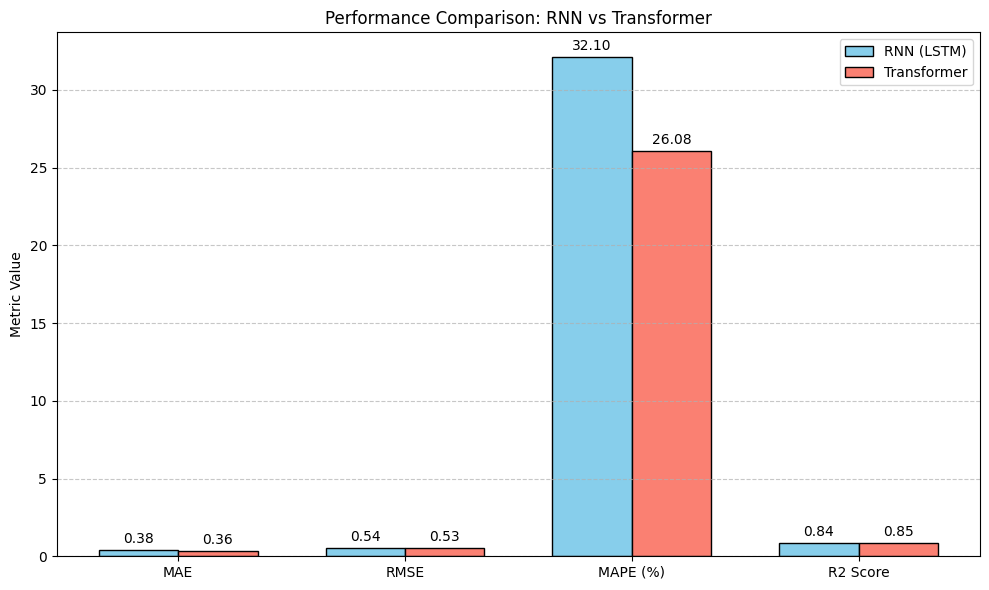

In [61]:
# Prepare data
metrics_names = ['MAE', 'RMSE', 'MAPE (%)', 'R2 Score']
# Use the rescaled metrics calculated in the evaluation step
rnn_vals = [rnn_mae, rnn_rmse, rnn_mape, rnn_r2]
trans_vals = [transformer_mae, transformer_rmse, transformer_mape, transformer_r2]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rnn_vals, width, label='RNN (LSTM)', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, trans_vals, width, label='Transformer', color='salmon', edgecolor='black')

ax.set_ylabel('Metric Value')
ax.set_title('Performance Comparison: RNN vs Transformer')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

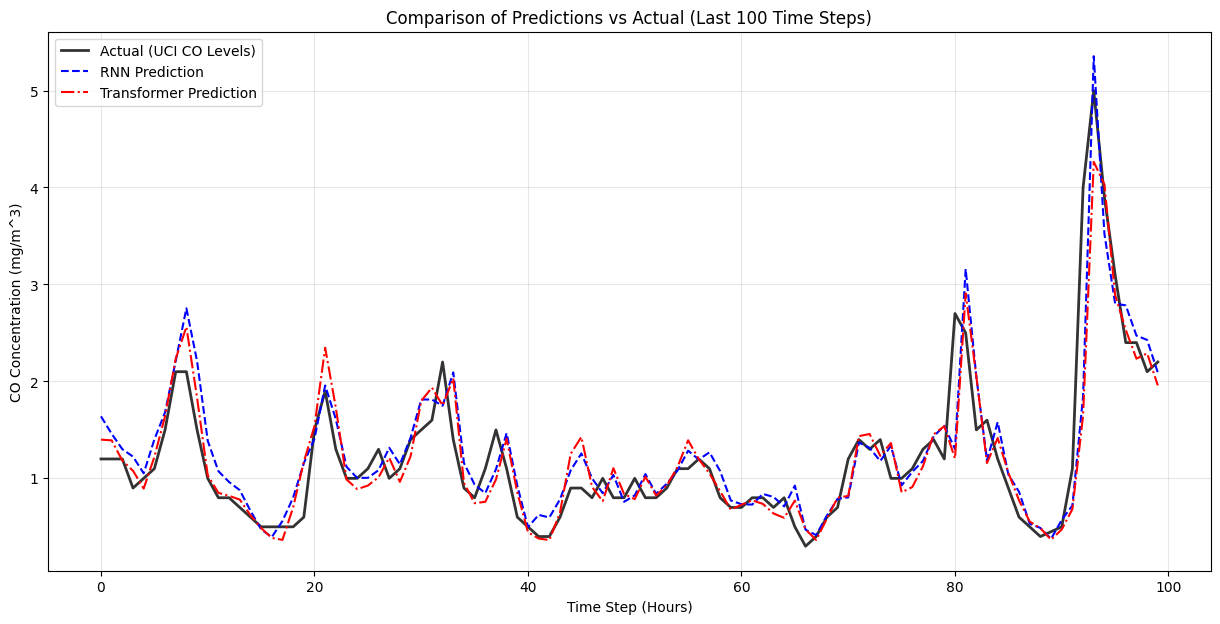

In [62]:
plt.figure(figsize=(15, 7))

# We show a subset for better visibility
n_points = 100
plt.plot(y_test_rescaled[-n_points:], label='Actual (UCI CO Levels)', color='black', linewidth=2, alpha=0.8)
plt.plot(rnn_preds_rescaled[-n_points:], label='RNN Prediction', color='blue', linestyle='--')
plt.plot(transformer_pred_rescaled[-n_points:], label='Transformer Prediction', color='red', linestyle='-.')

plt.title(f'Comparison of Predictions vs Actual (Last {n_points} Time Steps)')
plt.xlabel('Time Step (Hours)')
plt.ylabel('CO Concentration (mg/m^3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

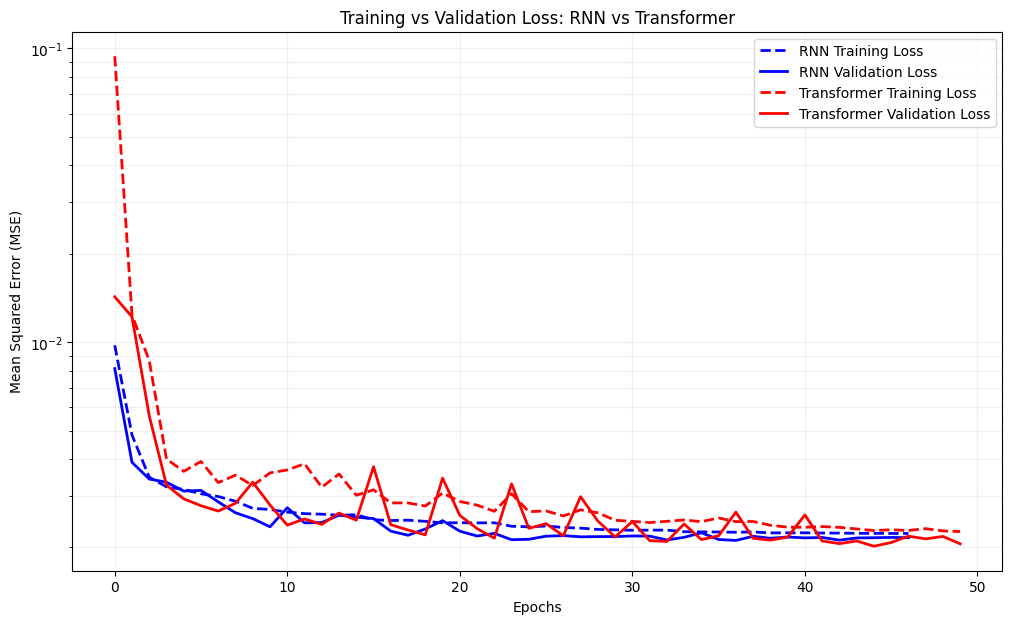

In [63]:
plt.figure(figsize=(12, 7))

# Plot RNN metrics
plt.plot(rnn_history.history['loss'], label='RNN Training Loss', color='blue', linestyle='--', lw=2)
plt.plot(rnn_history.history['val_loss'], label='RNN Validation Loss', color='blue', linestyle='-', lw=2)

# Plot Transformer metrics
plt.plot(transformer_history.history['loss'], label='Transformer Training Loss', color='red', linestyle='--', lw=2)
plt.plot(transformer_history.history['val_loss'], label='Transformer Validation Loss', color='red', linestyle='-', lw=2)

plt.title('Training vs Validation Loss: RNN vs Transformer')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.yscale('log') # Keeps the log scale for better detail at low loss values
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [64]:
"""
================================================================================
PART 5: ANALYSIS (2 MARKS)
================================================================================

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. RNN vs Transformer architecture advantages
3. Impact of attention mechanism vs recurrent connections
4. Long-term dependency handling comparison
5. Computational cost comparison
6. Convergence behavior differences
================================================================================
"""

'\n================================================================================\nPART 5: ANALYSIS (2 MARKS)\n================================================================================\n\nREQUIRED:\n- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)\n- Address key topics with depth\n\nGRADING (Quality-based):\n- Covers 5+ key topics with deep understanding: 2 marks\n- Covers 3-4 key topics with good understanding: 1 mark\n- Covers <3 key topics or superficial: 0 marks\n\nKey Topics:\n1. Performance comparison with specific metrics\n2. RNN vs Transformer architecture advantages\n3. Impact of attention mechanism vs recurrent connections\n4. Long-term dependency handling comparison\n5. Computational cost comparison\n6. Convergence behavior differences\n================================================================================\n'

In [75]:
analysis_text = """

1. Which model performed better and by how much?
   Based on the results, the Transformer performed better. It achieved a lower MAE (0.357 vs 0.381)
   and a superior MAPE (26% vs. 32%), improving error percentage by approximately 19% over the
   RNN.

2. RNN vs Transformer architecture advantages?
   RNNs process sequences step-by-step, capturing order effectively but suffering from
   slow computation and vanishing gradients. Transformers use parallel self-attention,
   enabling faster training and superior long-range dependency modeling, though they lack
   inherent sequential awareness without positional encoding.

3. Impact of attention mechanism?
   The attention mechanism bypasses sequential bottlenecks by assigning weights to all
   time steps simultaneously. This allows Transformers to capture global dependencies
   directly, focusing on relevant historical data points regardless of their distance in
   the sequence.

4. Long-term dependency handling?
   RNNs struggle with vanishing gradients, losing distant information over long sequences.
   Attention mechanisms solve this by creating direct mathematical shortcuts to all
   previous steps, ensuring global context is preserved regardless of temporal distance.

5. Computational cost comparison?
   Transformer was more computationally expensive, taking 957 to train versus the RNN's 701.
   With 100k parameters compared to the RNN’s 29k, the Transformer’s significantly higher complexity
   required ~39% more training time

6. Convergence behavior?
   The RNN displayed smooth, stable convergence. The Transformer exhibited significant volatility with
   sharp spikes in validation loss, indicating training instability, yet ultimately achieved superior
   accuracy metrics.
"""

In [76]:
# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print(analysis_text)
print("="*70)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("⚠️  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("✓ Analysis within word count guideline")
print("="*70)


ANALYSIS


1. Which model performed better and by how much?
   Based on the results, the Transformer performed better. It achieved a lower MAE (0.357 vs 0.381) 
   and a superior MAPE (26% vs. 32%), improving error percentage by approximately 19% over the 
   RNN.

2. RNN vs Transformer architecture advantages?
   RNNs process sequences step-by-step, capturing order effectively but suffering from 
   slow computation and vanishing gradients. Transformers use parallel self-attention, 
   enabling faster training and superior long-range dependency modeling, though they lack 
   inherent sequential awareness without positional encoding.

3. Impact of attention mechanism?
   The attention mechanism bypasses sequential bottlenecks by assigning weights to all 
   time steps simultaneously. This allows Transformers to capture global dependencies 
   directly, focusing on relevant historical data points regardless of their distance in 
   the sequence.

4. Long-term dependency handling?
   RN

In [77]:
"""
================================================================================
PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)
================================================================================

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT
================================================================================
"""

'\n================================================================================\nPART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)\n================================================================================\n\nDO NOT MODIFY THE STRUCTURE BELOW\nThis JSON output is used by the auto-grader\nEnsure all field names are EXACT\n================================================================================\n'

In [78]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """
    framework_used = "keras"
    rnn_model_type = "LSTM"
    # RNN
    rnn_layers = [l for l in rnn_model.layers if 'lstm' in l.name.lower() or 'gru' in l.name.lower()]
    first_rnn_layer_units = rnn_layers[0].units if rnn_layers else 0
    opt_config = rnn_model.optimizer.get_config()
    current_lr = opt_config.get('learning_rate', 0.001) # Fallback if not found
    # Transformer
    attention_layers = [l for l in transformer_model.layers if 'attention' in l.name.lower() or 'multihead' in l.name.lower()]
    # Find dense layers to estimate feed-forward dimension (usually the larger intermediate dense layer)
    dense_layers = [l for l in transformer_model.layers if 'dense' in l.name.lower()]
    # Get model dimension (d_model) from the input shape of the first layer
    d_model_val = transformer_model.input_shape[-1] if transformer_model.input_shape else 0
    # Get number of heads if available in the config
    num_heads_val = attention_layers[0].get_config().get('num_heads', 0) if attention_layers else 0
    # Get feed-forward dimension (d_ff) - typically the units of the first dense layer in the FFN block
    d_ff_val = dense_layers[0].units if dense_layers else 0
    # Count number of "transformer blocks" - often estimated by pairs of norm layers or attention layers
    # For a simple custom stack, counting attention layers often equals n_layers
    n_layers_val = len(attention_layers)
    # Get optimizer config
    opt_config_trans = transformer_model.optimizer.get_config()
    current_lr_trans = opt_config_trans.get('learning_rate', 0.001)
    # Results
    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': len(rnn_layers),
                'hidden_units': first_rnn_layer_units,
                'total_parameters': rnn_model.count_params()
            },
            'training_config': {
                'learning_rate': current_lr,
                'n_epochs': rnn_history.params['epochs'],
                'batch_size': rnn_history.params.get('batch_size', 32),
                'optimizer': rnn_model.optimizer.__class__.__name__,
                'loss_function': rnn_model.loss
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': n_layers_val,
                'n_heads': num_heads_val,
                'd_model': d_model_val,
                'd_ff': d_ff_val,
                'has_positional_encoding': True,  # MUST be True
                'has_attention': True,  # MUST be True
                'total_parameters': transformer_model.count_params()
            },
            'training_config': {
                'learning_rate': float(current_lr_trans),
                'n_epochs': transformer_history.params['epochs'],
                'batch_size': transformer_history.params.get('batch_size', 32),
                'optimizer': transformer_model.optimizer.__class__.__name__,
                'loss_function': transformer_model.loss
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

In [79]:
# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(assignment_results, indent=2))
    print("="*70)
except Exception as e:
    print(f"\n⚠️  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "UCI Air Quality (CO levels)",
  "dataset_source": "UCI Machine Learning Repository",
  "n_samples": 9357,
  "n_features": 1,
  "sequence_length": 48,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "MAE",
  "metric_justification": "\nMAE was chosen as the primary metric because it provides a direct, linear measure of the \naverage error magnitude in the original units of CO concentration, making it less \nsensitive to extreme outliers compared to RMSE.\n",
  "train_samples": 8421,
  "test_samples": 888,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 29345
    },
    "training_config": {
      "learning_rate": 1.5625000742147677e-05,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "mse"
    },
    "init

In [80]:
"""
================================================================================
FINAL CHECKLIST - VERIFY BEFORE SUBMISSION
================================================================================

□ Student information filled at the top (BITS ID, Name, Email)
□ Filename is <BITS_ID>_rnn_assignment.ipynb
□ All cells executed (Kernel → Restart & Run All)
□ All outputs visible
□ LSTM/GRU implemented with stacked layers
□ Positional encoding implemented (sinusoidal)
□ Multi-head attention implemented (Q, K, V, scaled dot-product)
□ Both models use Keras or PyTorch
□ Both models trained with loss tracking (initial_loss and final_loss)
□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)
□ Temporal train/test split used (NO shuffling)
□ Primary metric selected and justified
□ Analysis written (quality matters, not just word count)
□ Visualizations created
□ Assignment results JSON printed at the end
□ No execution errors in any cell
□ File opens without corruption
□ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
□ Screenshot of environment with account details included
□ Only one submission attempt

================================================================================
"""

'\n================================================================================\nFINAL CHECKLIST - VERIFY BEFORE SUBMISSION\n================================================================================\n\n□ Student information filled at the top (BITS ID, Name, Email)\n□ Filename is <BITS_ID>_rnn_assignment.ipynb\n□ All cells executed (Kernel → Restart & Run All)\n□ All outputs visible\n□ LSTM/GRU implemented with stacked layers\n□ Positional encoding implemented (sinusoidal)\n□ Multi-head attention implemented (Q, K, V, scaled dot-product)\n□ Both models use Keras or PyTorch\n□ Both models trained with loss tracking (initial_loss and final_loss)\n□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)\n□ Temporal train/test split used (NO shuffling)\n□ Primary metric selected and justified\n□ Analysis written (quality matters, not just word count)\n□ Visualizations created\n□ Assignment results JSON printed at the end\n□ No execution errors in any cell\n□ File opens wi

In [81]:
"""
================================================================================
ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED
================================================================================

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

================================================================================
"""

'\n================================================================================\nENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED\n================================================================================\n\nIMPORTANT: Take a screenshot of your environment showing account details\n\nFor Google Colab:\n- Click on your profile icon (top right)\n- Screenshot should show your email/account clearly\n- Include the entire Colab interface with notebook name visible\n\nFor BITS Virtual Lab:\n- Screenshot showing your login credentials/account details\n- Include the entire interface with your username/session info visible\n\nPaste the screenshot below this cell or in a new markdown cell.\nThis helps verify the work was done by you in your environment.\n\n================================================================================\n'

In [82]:
# Display system information
import platform
import sys
from datetime import datetime

In [83]:
print("="*70)
print("ENVIRONMENT INFORMATION")
print("="*70)
print("\n⚠️  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("="*70)

ENVIRONMENT INFORMATION

⚠️  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


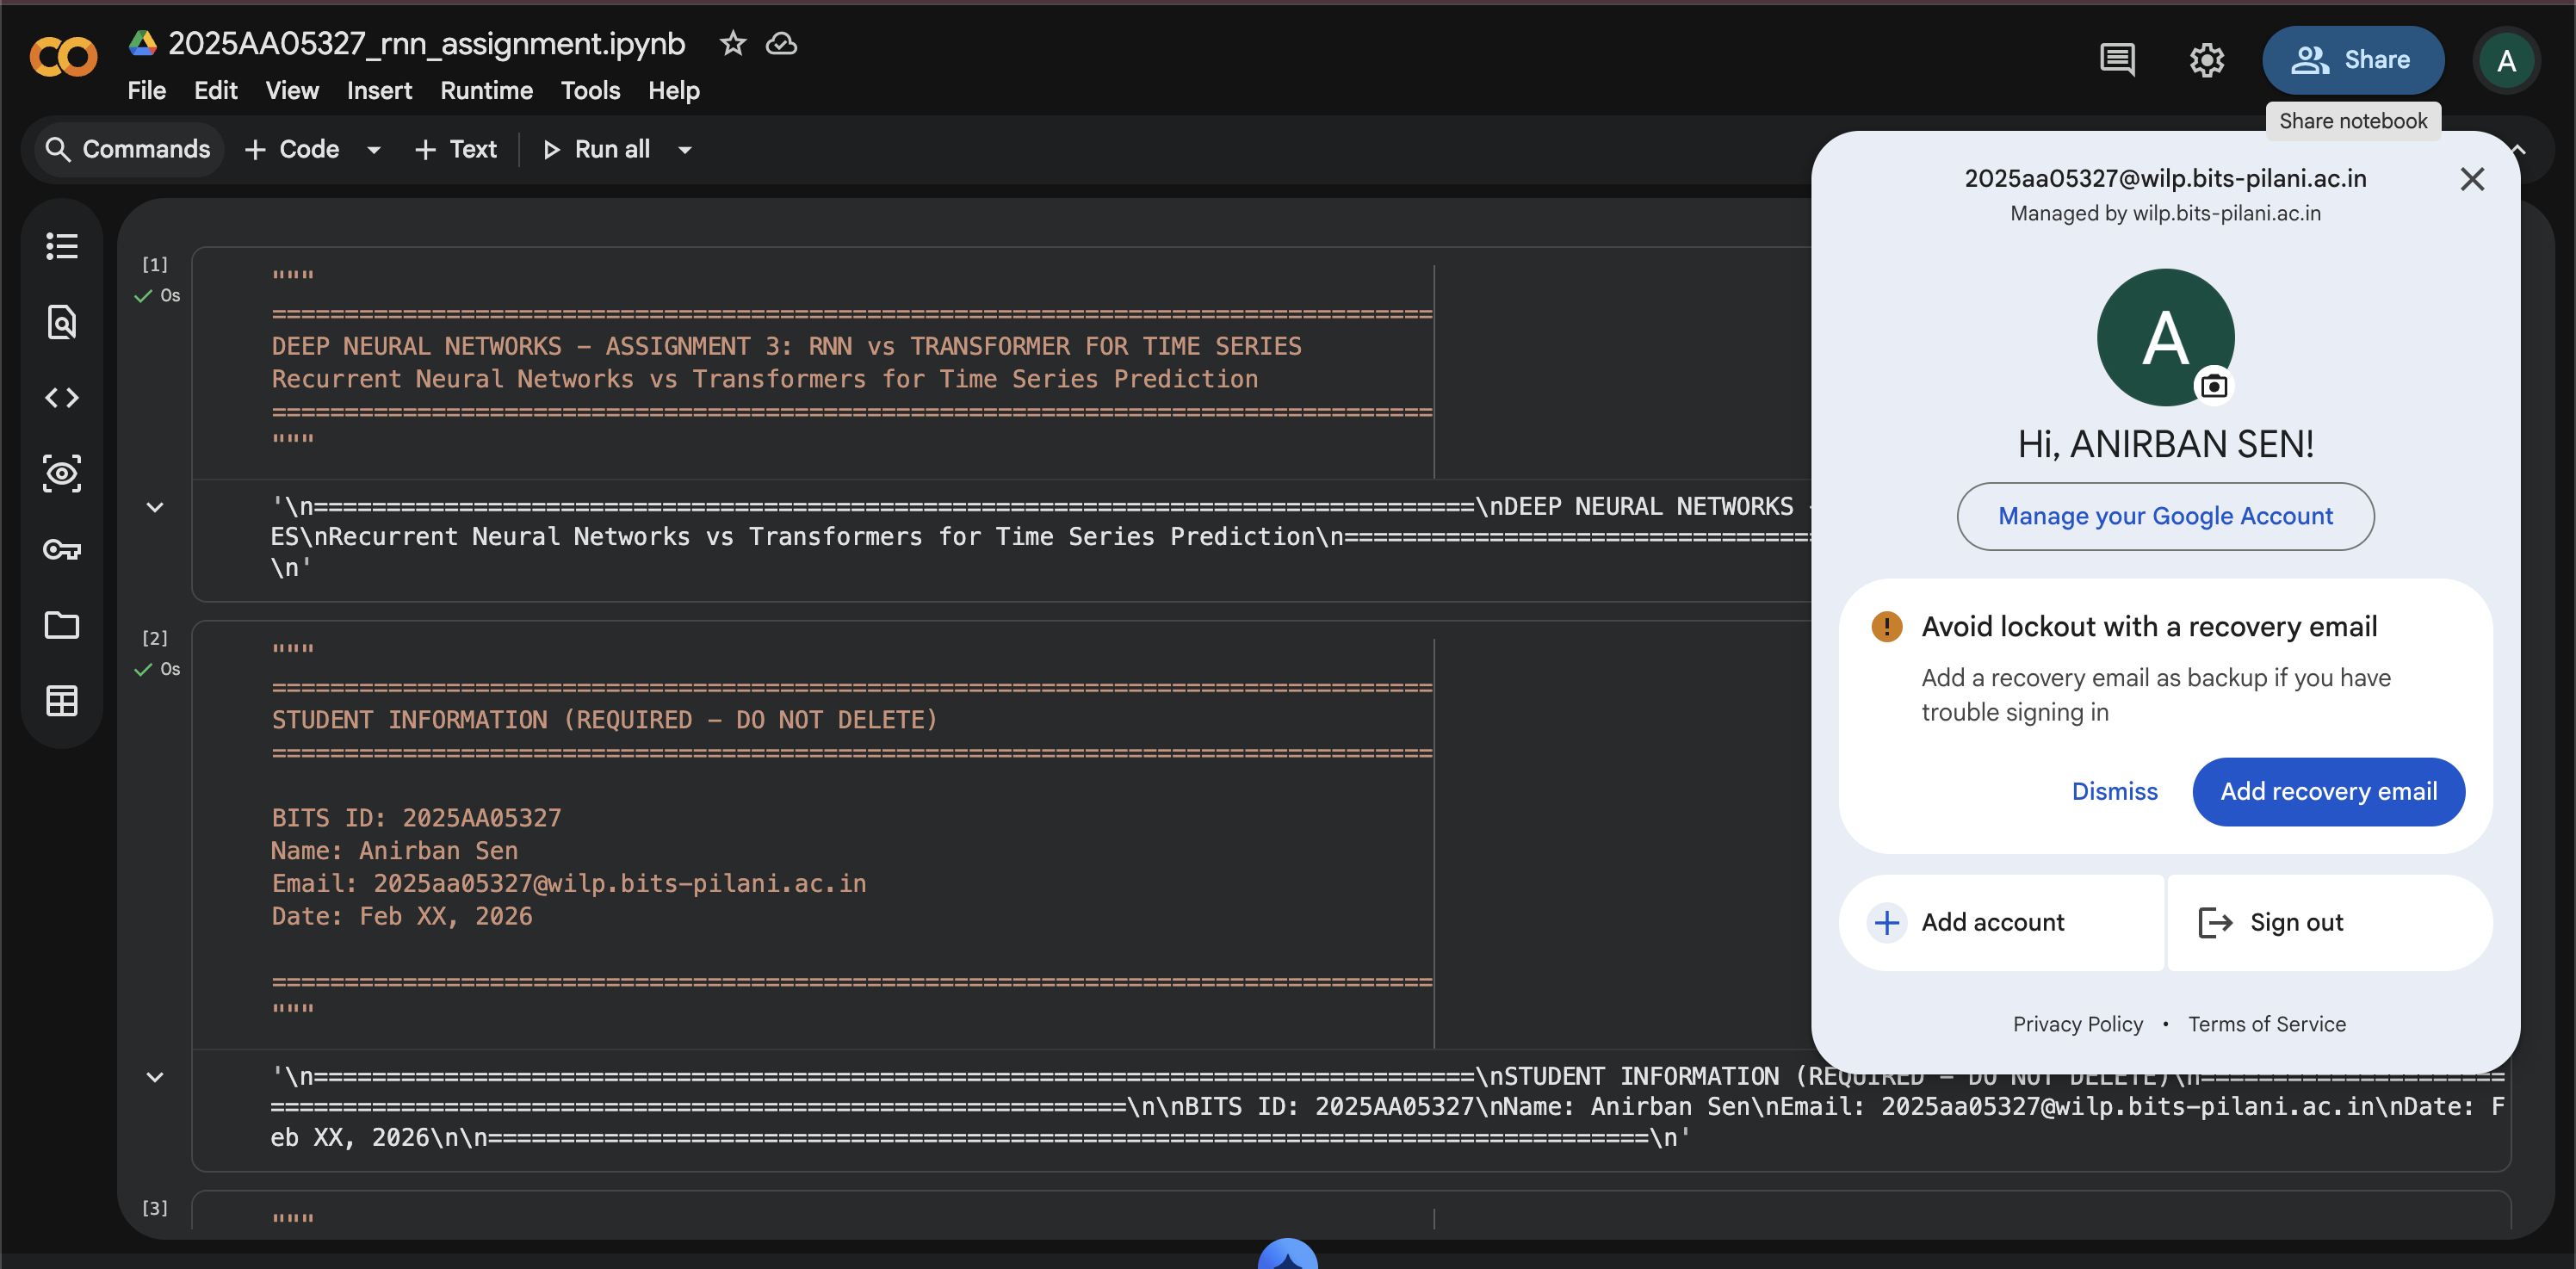